In [11]:
import pandas as pd

df = pd.read_csv("data.csv")

In [12]:
df.drop(["date", "statezip","country"] , axis=1, inplace=True)
df.shape

(4600, 15)

In [13]:
df.dropna(axis=0, inplace=True)

In [14]:
df.shape

(4600, 15)

In [15]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond


In [16]:
from sklearn import linear_model, preprocessing


encoder = preprocessing.LabelEncoder()

streedData = df['street'].values
df['street']=encoder.fit_transform(streedData)

cityData = df['city'].values
df['city']=encoder.fit_transform(cityData)



In [17]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,1522,36
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,3899,35
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,2291,18
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,4263,3
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,4352,31


In [18]:
from sklearn.utils import shuffle

df = shuffle(df, random_state=42)[:700]

In [19]:
df.shape

(700, 15)

In [46]:
from sklearn.utils import shuffle
import numpy as np

# Shuffle the dataset with 10 different seeds
seeds = [13, 41, 75, 12, 37, 69, 70, 88, 9, 0]
df_shuffled = []
for seed in seeds:
    df_shuffled.append(shuffle(df, random_state=seed))

In [47]:
Y = df["price"]
x = df.drop("price",axis=1)

In [48]:
df_shuffled[0].iloc[:, 1:]

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city
3550,2.0,2.25,1330,10838,2.0,0,0,3,1330,0,1985,0,1586,17
4518,3.0,1.75,1880,11249,1.0,0,0,3,1330,550,1985,0,2107,1
2312,4.0,2.25,2030,13500,1.0,0,0,3,1230,800,1963,2008,1729,32
3810,3.0,1.75,1540,3000,1.0,0,2,3,770,770,1920,1979,3800,35
3533,3.0,2.50,1660,1545,2.0,0,2,3,1400,260,2002,0,4159,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1726,2.0,2.50,1175,1366,2.0,0,0,3,740,435,2005,0,4380,35
463,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,4171,35
1186,3.0,1.75,1610,7200,1.0,0,0,3,1090,520,1973,2013,53,35
376,3.0,1.75,1460,7700,1.0,0,0,3,1460,0,1979,2014,1116,31


In [53]:
from sklearn.model_selection import train_test_split

# Split the dataset into train and test sets for 10 times
train_test_sets = []
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(df_shuffled[i].iloc[:, 1:], 
                                                        df_shuffled[i].iloc[:, 0], 
                                                        test_size=0.3, 
                                                        )
    train_test_sets.append((X_train, X_test, y_train, y_test))

In [54]:
from sklearn.linear_model import LinearRegression

# Train the regression model for 10 times
models = []
for i in range(10):
    model = LinearRegression()
    model.fit(train_test_sets[i][0], train_test_sets[i][2])
    models.append(model)


In [55]:
from sklearn.metrics import mean_squared_error, r2_score

# Test the regression model for 10 times and calculate MSE and R^2 score
mse_scores = []
r2_scores = []
for i in range(10):
    y_pred = models[i].predict(train_test_sets[i][1])
    mse_scores.append(mean_squared_error(train_test_sets[i][3], y_pred))
    r2_scores.append(r2_score(train_test_sets[i][3], y_pred))


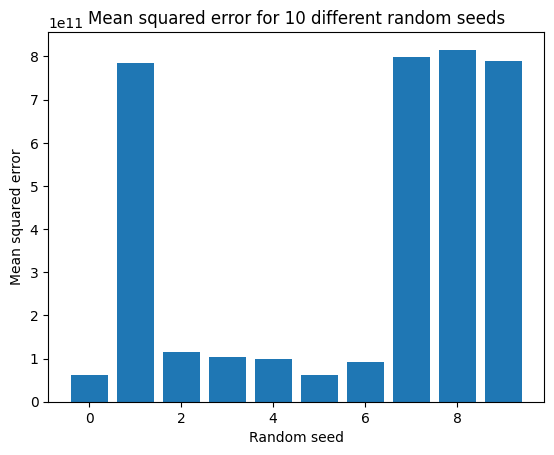

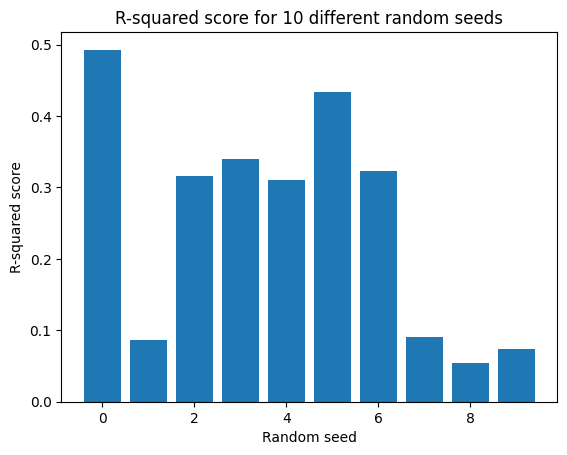

In [56]:
import matplotlib.pyplot as plt

# Draw bar graph for MSE
plt.bar(range(10), mse_scores)
plt.xlabel("Random seed")
plt.ylabel("Mean squared error")
plt.title("Mean squared error for 10 different random seeds")
plt.show()

# Draw bar graph for R^2 score
plt.bar(range(10), r2_scores)
plt.xlabel("Random seed")
plt.ylabel("R-squared score")
plt.title("R-squared score for 10 different random seeds")
plt.show()
